In [1]:
print("hi")

hi


In [2]:
from __future__ import annotations

import os
import textwrap
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

warnings.filterwarnings("ignore")


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "fastf1_race_level_2018_2025.csv"
MODEL_PATH = PROJECT_ROOT / "artifacts" / "f1_module1_race_models.joblib"

print("Data file:", DATA_PATH)
print("Model file:", MODEL_PATH)

Data file: /Users/santhoshkumarv/vs_code_projects/internship-harshith/projects/capstone_project/data/fastf1_race_level_2018_2025.csv
Model file: /Users/santhoshkumarv/vs_code_projects/internship-harshith/projects/capstone_project/artifacts/f1_module1_race_models.joblib


In [4]:
artifact = joblib.load(MODEL_PATH)

winner_model = artifact["winner_model"]
feature_columns = artifact["feature_columns"]
categorical_features = artifact.get("categorical_features", [])
numeric_features = artifact.get("numeric_features", [])


In [5]:

print("Loaded artifact keys:", sorted(artifact.keys()))
print("Winner model:", artifact.get("winner_model_name", type(winner_model).__name__))
print("Feature count:", len(feature_columns))
print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)


Loaded artifact keys: ['categorical_features', 'created_utc', 'feature_columns', 'holdout_year', 'numeric_features', 'package_versions', 'podium_best_params', 'podium_metrics_unseen_season', 'podium_model', 'podium_model_name', 'training_years', 'winner_best_params', 'winner_metrics_unseen_season', 'winner_model', 'winner_model_name']
Winner model: LightGBM
Feature count: 20
Categorical features: ['driver', 'team', 'location', 'country', 'event_format']
Numeric features: ['season', 'round', 'season_progress', 'grid_position', 'driver_prior_starts', 'driver_avg_finish_5', 'driver_avg_points_5', 'driver_avg_grid_5', 'driver_dnf_rate_5', 'driver_prior_win_rate', 'driver_prior_podium_rate', 'driver_circuit_avg_finish', 'team_avg_points_5', 'team_avg_best_finish_5', 'team_avg_podiums_5']


In [6]:
def add_driver_history(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    data["dnf"] = ~data["status"].str.contains(
        r"Finished|\+\d+ Lap", regex=True, case=False, na=False
    )
    data["dnf"] = data["dnf"].astype(int)

    group = data.groupby("driver", group_keys=False, sort=False)
    data["driver_prior_starts"] = group.cumcount()

    for source, new_name in [
        ("finish_position", "driver_avg_finish_5"),
        ("points", "driver_avg_points_5"),
        ("grid_position", "driver_avg_grid_5"),
        ("dnf", "driver_dnf_rate_5"),
    ]:
        data[new_name] = group[source].transform(
            lambda s: s.shift(1).rolling(5, min_periods=1).mean()
        )

    data["driver_prior_win_rate"] = group["winner"].transform(
        lambda s: s.shift(1).expanding(min_periods=1).mean()
    )
    data["driver_prior_podium_rate"] = group["podium"].transform(
        lambda s: s.shift(1).expanding(min_periods=1).mean()
    )

    circuit_group = data.groupby(["driver", "location"], group_keys=False, sort=False)
    data["driver_circuit_avg_finish"] = circuit_group["finish_position"].transform(
        lambda s: s.shift(1).expanding(min_periods=1).mean()
    )
    return data



In [ ]:
def add_team_history(data: pd.DataFrame) -> pd.DataFrame:
    event_keys = ["season", "round", "event_date", "team"]
    team_race = (
        data.groupby(event_keys, as_index=False)
        .agg(
            team_race_points=("points", "sum"),
            team_best_finish=("finish_position", "min"),
            team_podiums=("podium", "sum"),
        )
        .sort_values(["event_date", "season", "round", "team"])
    )

    team_group = team_race.groupby("team", group_keys=False, sort=False)
    team_race["team_avg_points_5"] = team_group["team_race_points"].transform(
        lambda s: s.shift(1).rolling(5, min_periods=1).mean()
    )
    team_race["team_avg_best_finish_5"] = team_group["team_best_finish"].transform(
        lambda s: s.shift(1).rolling(5, min_periods=1).mean()
    )
    team_race["team_avg_podiums_5"] = team_group["team_podiums"].transform(
        lambda s: s.shift(1).rolling(5, min_periods=1).mean()
    )

    return data.merge(
        team_race[event_keys + ["team_avg_points_5", "team_avg_best_finish_5", "team_avg_podiums_5"]],
        on=event_keys,
        how="left",
        validate="many_to_one",
    )


In [8]:
def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    featured = add_driver_history(data)
    featured = add_team_history(featured)
    featured["season_progress"] = featured["round"] / featured.groupby("season")["round"].transform("max")
    featured["grid_position"] = featured["grid_position"].replace(0, np.nan)
    featured["event_key"] = (
        featured["season"].astype(str)
        + "_"
        + featured["round"].astype(int).astype(str).str.zfill(2)
    )
    return featured.sort_values(["event_date", "season", "round", "driver"]).reset_index(drop=True)

raw_data = pd.read_csv(DATA_PATH)
raw_data["event_date"] = pd.to_datetime(raw_data["event_date"])
model_data = engineer_features(raw_data)

missing = sorted(set(feature_columns) - set(model_data.columns))
if missing:
    raise ValueError(f"The dataset is missing required model features: {missing}")

print("Rows:", len(model_data))
print("Races:", model_data["event_key"].nunique())
display(model_data[["season", "round", "event_name", "driver", "team", "grid_position", "winner"]].tail())


Rows: 800
Races: 41


,season,round,event_name,driver,team,grid_position,winner
795,2025,5,Saudi Arabian Grand Prix,RUS,Mercedes,3.0,0
796,2025,5,Saudi Arabian Grand Prix,SAI,Williams,6.0,0
797,2025,5,Saudi Arabian Grand Prix,STR,Aston Martin,16.0,0
798,2025,5,Saudi Arabian Grand Prix,TSU,Red Bull,8.0,0
799,2025,5,Saudi Arabian Grand Prix,VER,Red Bull,1.0,0


In [9]:
def predict_race(field: pd.DataFrame, model, features: list[str]) -> pd.DataFrame:
    raw_probability = model.predict_proba(field[features])[:, 1]
    total = raw_probability.sum()
    race_probability = raw_probability / total if total > 0 else np.repeat(1 / len(field), len(field))

    output = field[["season", "round", "event_name", "event_key", "driver", "team", "grid_position", "winner"]].copy()
    output["winner_probability"] = race_probability
    output["raw_model_probability"] = raw_probability
    output["rank"] = output["winner_probability"].rank(method="first", ascending=False).astype(int)
    return output.sort_values("winner_probability", ascending=False).reset_index(drop=True)


In [10]:
# Pick the latest race in the dataset. Change SAMPLE_EVENT_KEY to explain a different race.
SAMPLE_EVENT_KEY = model_data.sort_values("event_date")["event_key"].iloc[-1]
sample_field = model_data.loc[model_data["event_key"] == SAMPLE_EVENT_KEY].copy()
sample_prediction = predict_race(sample_field, winner_model, feature_columns)

predicted = sample_prediction.iloc[0]
actual_winner = sample_prediction.loc[sample_prediction["winner"] == 1, "driver"].iloc[0]

print("Prediction")
print(f"Race: {predicted['event_name']} ({int(predicted['season'])}, round {int(predicted['round'])})")
print(f"Winner: {predicted['driver']}")
print(f"Probability: {predicted['winner_probability']:.0%}")
print(f"Actual winner in dataset: {actual_winner}")


Prediction
Race: Saudi Arabian Grand Prix (2025, round 5)
Winner: VER
Probability: 46%
Actual winner in dataset: PIA


In [11]:
display(
    sample_prediction[["rank", "driver", "team", "grid_position", "winner_probability", "winner"]]
    .head(10)
    .style.format({"grid_position": "{:.0f}", "winner_probability": "{:.1%}"})
)

,rank,driver,team,grid_position,winner_probability,winner
0,1,VER,Red Bull,1,46.4%,0
1,2,PIA,McLaren,2,37.5%,1
2,3,RUS,Mercedes,3,8.6%,0
3,4,NOR,McLaren,10,2.9%,0
4,5,LEC,Ferrari,4,1.5%,0
5,6,ANT,Mercedes,5,0.6%,0
6,7,SAI,Williams,6,0.4%,0
7,8,TSU,Red Bull,8,0.3%,0
8,9,HAM,Ferrari,7,0.2%,0
9,10,STR,Aston Martin,16,0.2%,0


In [12]:
def get_transformed_feature_names(pipeline) -> np.ndarray:
    preprocessor = pipeline.named_steps["preprocessor"]
    return preprocessor.get_feature_names_out()


In [13]:
def plot_model_feature_importance(pipeline, top_n: int = 20) -> pd.DataFrame:
    model = pipeline.named_steps["model"]
    feature_names = get_transformed_feature_names(pipeline)

    if not hasattr(model, "feature_importances_"):
        raise AttributeError("The selected model does not expose feature_importances_. Use SHAP instead.")

    importance = pd.DataFrame(
        {"feature": feature_names, "importance": np.asarray(model.feature_importances_)}
    ).sort_values("importance", ascending=False)

    top = importance.head(top_n).sort_values("importance")
    plt.figure(figsize=(10, 7))
    plt.barh(top["feature"], top["importance"], color="#d62728")
    plt.title("Winner Model Feature Importance")
    plt.xlabel("Model importance")
    plt.tight_layout()
    plt.show()
    return importance


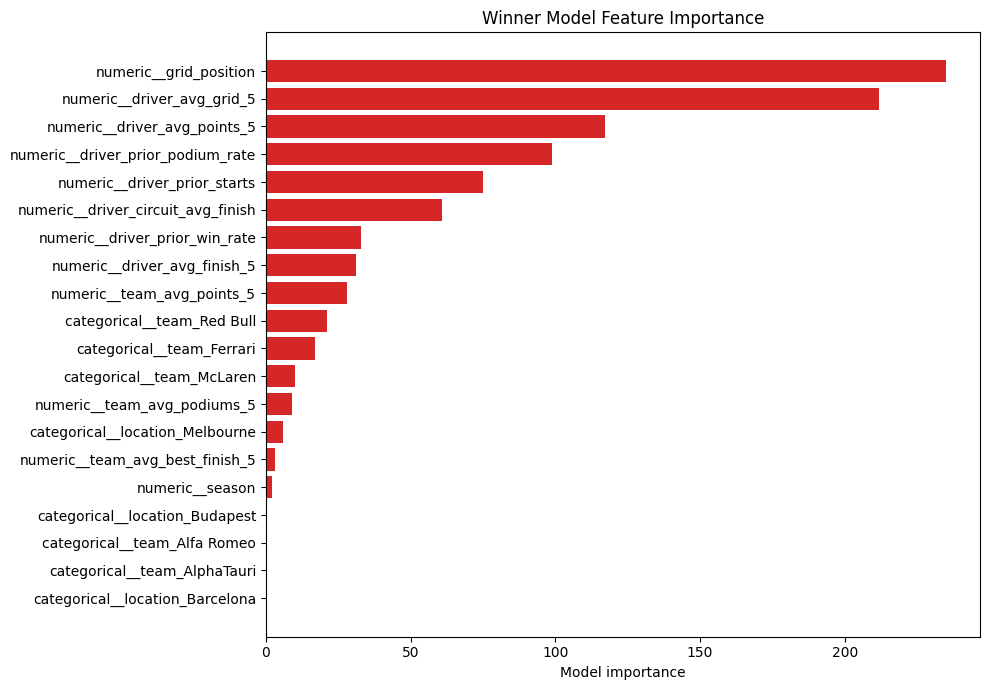

,feature,importance
3,numeric__grid_position,235
7,numeric__driver_avg_grid_5,212
6,numeric__driver_avg_points_5,117
10,numeric__driver_prior_podium_rate,99
4,numeric__driver_prior_starts,75
11,numeric__driver_circuit_avg_finish,61
9,numeric__driver_prior_win_rate,33
5,numeric__driver_avg_finish_5,31
12,numeric__team_avg_points_5,28
77,categorical__team_Red Bull,21


In [ ]:
feature_importance = plot_model_feature_importance(winner_model, top_n=20)
display(feature_importance.head(15))

In [15]:
def to_dense(matrix):
    return matrix.toarray() if hasattr(matrix, "toarray") else np.asarray(matrix)

preprocessor = winner_model.named_steps["preprocessor"]
final_model = winner_model.named_steps["model"]
transformed_feature_names = get_transformed_feature_names(winner_model)

background_rows = model_data[feature_columns].sample(
    n=min(200, len(model_data)), random_state=42
)
background_X = to_dense(preprocessor.transform(background_rows))
race_X = to_dense(preprocessor.transform(sample_field[feature_columns]))

predicted_driver = predicted["driver"]
predicted_row_index = sample_field.reset_index(drop=True).index[
    sample_field.reset_index(drop=True)["driver"].eq(predicted_driver)
][0]
predicted_X = race_X[[predicted_row_index]]

print("Background SHAP shape:", background_X.shape)
print("Race SHAP shape:", race_X.shape)
print("Predicted driver explained:", predicted_driver)


Background SHAP shape: (200, 111)
Race SHAP shape: (20, 111)
Predicted driver explained: VER


In [16]:
def shap_values_for_positive_class(explainer, values):
    shap_values = explainer(values)

    # Binary classifiers may return either a 2D matrix or a 3D matrix with one output per class.
    if getattr(shap_values, "values", None) is not None and shap_values.values.ndim == 3:
        return shap.Explanation(
            values=shap_values.values[:, :, 1],
            base_values=shap_values.base_values[:, 1],
            data=shap_values.data,
            feature_names=shap_values.feature_names,
        )
    return shap_values


In [17]:
explainer = shap.Explainer(final_model, background_X, feature_names=transformed_feature_names)
race_shap = shap_values_for_positive_class(explainer, race_X)
predicted_shap = shap_values_for_positive_class(explainer, predicted_X)

print("SHAP values computed for the selected race.")
print("Expected/base value:", np.ravel(predicted_shap.base_values)[0])


SHAP values computed for the selected race.
Expected/base value: -5.071613854328147


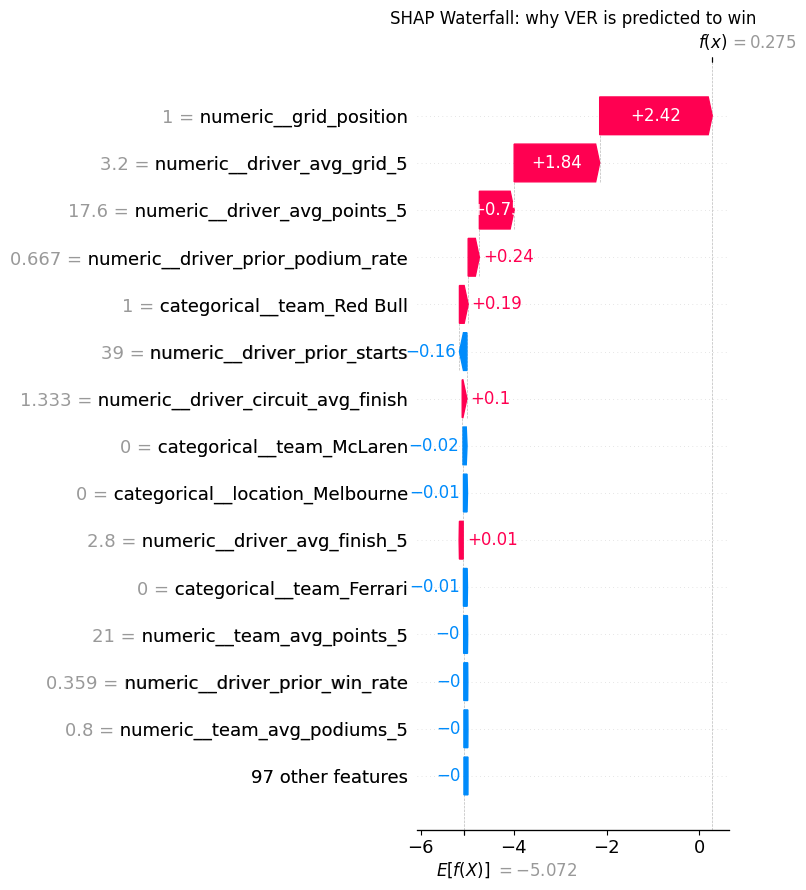

In [18]:
#Waterfall plot
plt.figure(figsize=(10, 7))
shap.plots.waterfall(predicted_shap[0], max_display=15, show=False)
plt.title(f"SHAP Waterfall: why {predicted_driver} is predicted to win")
plt.tight_layout()
plt.show()


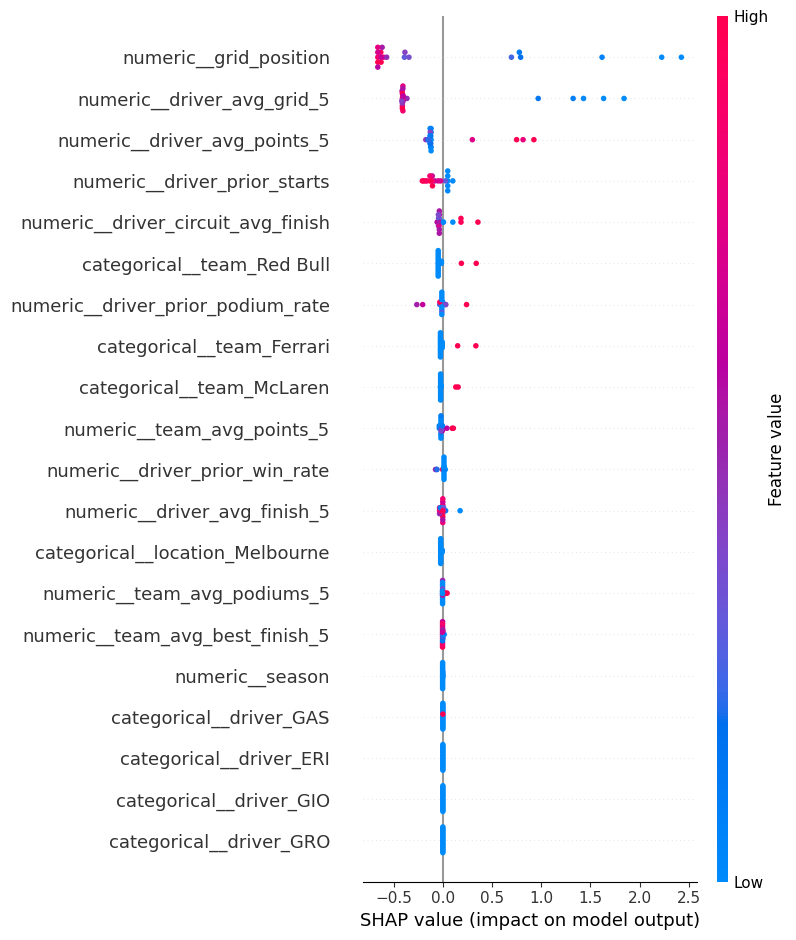

In [19]:
shap.summary_plot(
    race_shap.values,
    race_X,
    feature_names=transformed_feature_names,
    max_display=20,
    show=True,
)


In [ ]:
def clean_feature_name(name: str) -> str:
    cleaned = name
    for prefix in ["numeric__", "categorical__", "numbers__", "categories__"]:
        cleaned = cleaned.replace(prefix, "")
    cleaned = cleaned.replace("onehot__", "")
    cleaned = cleaned.replace("_", " ")
    return cleaned

In [21]:
def shap_reason_table(explanation, top_n: int = 10) -> pd.DataFrame:
    values = np.asarray(explanation.values[0])
    data_values = np.asarray(explanation.data[0])
    total_abs = np.abs(values).sum()
    table = pd.DataFrame(
        {
            "feature": transformed_feature_names,
            "feature_value": data_values,
            "shap_value": values,
        }
    )
    table["direction"] = np.where(table["shap_value"] >= 0, "helps prediction", "lowers prediction")
    table["contribution_pct"] = np.where(total_abs > 0, table["shap_value"] / total_abs * 100, 0)
    table["abs_contribution_pct"] = table["contribution_pct"].abs()
    table["feature"] = table["feature"].map(clean_feature_name)
    return table.sort_values("abs_contribution_pct", ascending=False).head(top_n)


In [22]:
reason_table = shap_reason_table(predicted_shap, top_n=12)

print("Why?")
display(
    reason_table[["feature", "feature_value", "direction", "contribution_pct", "shap_value"]]
    .style.format({"feature_value": "{:.3g}", "contribution_pct": "{:+.1f}%", "shap_value": "{:+.4f}"})
)


Why?


,feature,feature_value,direction,contribution_pct,shap_value
3,grid position,1,helps prediction,+42.1%,+2.4237
7,driver avg grid 5,3.2,helps prediction,+32.0%,+1.8414
6,driver avg points 5,17.6,helps prediction,+13.0%,+0.7497
10,driver prior podium rate,0.667,helps prediction,+4.2%,+0.2407
77,team Red Bull,1,helps prediction,+3.3%,+0.1881
4,driver prior starts,39,lowers prediction,-2.8%,-0.1609
11,driver circuit avg finish,1.33,helps prediction,+1.8%,+0.1012
73,team McLaren,0,lowers prediction,-0.3%,-0.0174
87,location Melbourne,0,lowers prediction,-0.2%,-0.0097
5,driver avg finish 5,2.8,helps prediction,+0.1%,+0.0067


In [23]:
def make_plain_english_explanation(driver: str, probability: float, reasons: pd.DataFrame) -> str:
    positive = reasons.loc[reasons["shap_value"] > 0].head(3)
    negative = reasons.loc[reasons["shap_value"] < 0].head(2)

    positive_text = ", ".join(positive["feature"].tolist()) if len(positive) else "the overall feature profile"
    explanation = (
        f"The model predicts {driver} as the winner with a {probability:.0%} race-normalized probability. "
        f"The strongest reasons supporting this prediction are {positive_text}."
    )

    if len(negative):
        negative_text = ", ".join(negative["feature"].tolist())
        explanation += f" The main factors pulling the prediction down are {negative_text}."

    explanation += " The waterfall plot shows how each feature moves the prediction away from the model's average expectation."
    return explanation


In [24]:

human_explanation = make_plain_english_explanation(
    predicted_driver,
    float(predicted["winner_probability"]),
    reason_table,
)

print(textwrap.fill(human_explanation, width=110))


The model predicts VER as the winner with a 46% race-normalized probability. The strongest reasons supporting
this prediction are grid position, driver avg grid 5, driver avg points 5. The main factors pulling the
prediction down are driver prior starts, team McLaren. The waterfall plot shows how each feature moves the
prediction away from the model's average expectation.
